TODOs for improving stuff:
- Automatic data retrieval from quickfs, other APIs
- Automatic retraining and backtesting
- Use a CI to calculate the cutoff percentile
- Create an ensemble model (maybe with an LSTM implementation)
- Add in technical data (pandas_ta or ta-lib)

In [1]:
from quickfsfunctions import *

In [18]:
# Date to start training. Testing will occur one year later over the course of one year.
start_date = '2019-01-01'
num_stocks = 500
pct = 0.97
folder = 'all'
# If there is extended data, we can use more than one year
years = 0.25

model1 = XGBRegressor(objective="reg:absoluteerror", max_depth=7, n_estimators=1000, learning_rate=0.3)
model1 = train_ranking(model1, start_date, num_stocks, years, folder)[0]
model2 = CatBoostRegressor(max_depth=7, n_estimators=1000, learning_rate=0.3)
model2 = train_ranking(model2, start_date, num_stocks, years, folder)[0]
model3 = LGBMRegressor(max_depth=7, n_estimators=1000, learning_rate=0.3, verbose=-1)
model3 = train_ranking(model3, start_date, num_stocks, years, folder)[0]

test_start = add_days(start_date, years * 365)
print(f"Test start date: {test_start}")

model_list = [model1, model2, model3]
model_predictions, values = predict(model_list[0], test_start, num_stocks, years, folder)
predictions = model_predictions
for model in model_list[1:]:
    model_predictions, values = predict(model, test_start, num_stocks, years, folder)
    for i in range(len(model_predictions)):
        predictions[i] += model_predictions[i]
for i in range(len(predictions)):
    predictions[i] = predictions[i] / len(model_list)
    
pct_values = return_pct(predictions, values, pct=1-pct)[0]
# pct_values = remove_outliers(pct_values)
# This actually isn't realistic as we wouldn't ever discard incredibly high returns.
# However, it can be nice for the sake of comparison between different years.
print(f"Model MAE: {mean_absolute_error(predictions, values)}")
print(f"Average return over 1 quarter: {np.average(pct_values)}")
print(f"Total number of stocks invested in: {len(pct_values)}")

num_correct = 0
for value in pct_values:
        if value >= 0.03556:
            num_correct += 1
print(f"Investment Grade Precision: {num_correct / len(pct_values)}")

Test start date: 2019-04-02
Model MAE: 176.3807509424085
Average return over 1 quarter: 0.15534560241724213
Total number of stocks invested in: 10
Investment Grade Precision: 0.8


In [21]:
predictions, values = predict(model1, test_start, num_stocks, years, folder)
pct_values = return_pct(predictions, values, pct=1-pct)[0]
# pct_values = remove_outliers(pct_values)
# This actually isn't realistic as we wouldn't ever discard incredibly high returns.
# However, it can be nice for the sake of comparison between different years.
print(f"Model MAE: {mean_absolute_error(predictions, values)}")
print(f"Average return over 1 quarter: {np.average(pct_values)}")
print(f"Total number of stocks invested in: {len(pct_values)}")

num_correct = 0
for value in pct_values:
        if value >= 0.03556:
            num_correct += 1
print(f"Investment Grade Precision: {num_correct / len(pct_values)}")

Model MAE: 175.39557585076366
Average return over 1 quarter: 0.16535518689093232
Total number of stocks invested in: 10
Investment Grade Precision: 0.9


In [29]:
return_df = predict_df(model, test_start, num_stocks, years, folder, pct=1-pct)
returns = backtest(return_df, test_start, 1)
one_year_sharpe(returns)

1.5971721094688285

In [34]:
return_df

,Stock Ticker,Date,Return
0,RBLX,2023-04-02,-0.092913
1,PANW,2023-04-02,0.288319
2,SE,2023-04-02,-0.329590
3,MSTR,2023-04-02,0.192481
4,COIN,2023-04-02,0.108923
5,BIDU,2023-04-02,-0.052333
6,ALC,2023-04-02,0.163810
7,SPOT,2023-04-02,0.215155
8,HUBS,2023-04-02,0.251051
9,MRVL,2023-04-02,0.407492


Below is the feature importance for Apple's fundamental metrics when evaluated on data available before April 2nd, 2023.

In [8]:
model2 = XGBRegressor(objective="reg:absoluteerror", max_depth=7, n_estimators=1000, learning_rate=0.3)
model2, xlist = train_ranking(model2, test_start, num_stocks, years, folder)
df = feature_importance(model, [xlist[0]])

Text(0.5, 0, 'SHAP Value')

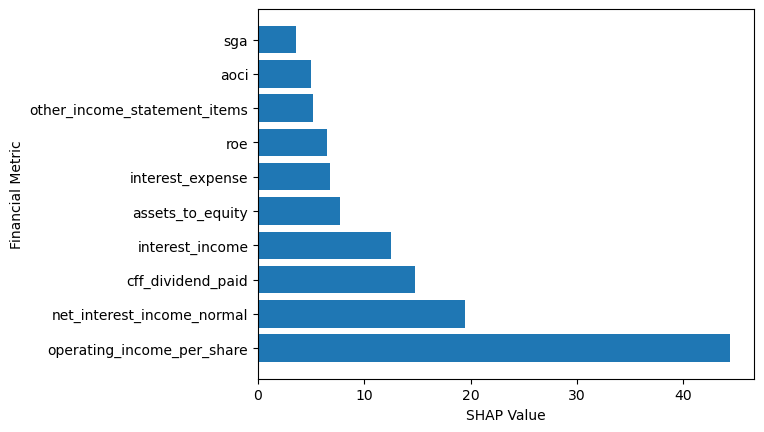

In [12]:
plt.barh(df.nlargest(10, columns="score").index, df.nlargest(10, columns="score")['score'])
plt.ylabel("Financial Metric")
plt.xlabel("SHAP Value")

In [65]:
results = pd.read_csv("data/experiments/quickFSrankingPrecision+Sharpe+Return2500_0.97", index_col=0)
print(len(results) / 5)
print(np.mean(results[results['metric'] == 'all']['Avg Return']))
for metric in ["all", "income_statement", "balance_sheet", "cash_flow_statement", "computed"]:
    print(metric, np.mean(results[results['metric'] == metric].iloc[:, 4]), np.std(results[results['metric'] == metric].iloc[:, 4]))

20.0
0.2000232762896191
all 0.7856656966801915 0.8013066946727518
income_statement 0.7280438672812144 0.7685592607185107
balance_sheet 0.6881476005482232 0.7134595048414842
cash_flow_statement 0.7155564340522197 0.7288532285225897
computed 0.7661749424368629 0.6572745127837856


Calculate historical sharpe ratios for S&P500 for comparison

In [40]:
data = pd.read_csv("data/yfinance/SPY.csv", index_col=0)
returns = pd.DataFrame()
returns['Return'] = data['2005-01-14':'2025-01-14']['Open']
one_year_sharpe(returns)

0.6110492953666133

In [99]:
data = pd.read_csv("data/experiments/featureImportance.csv", index_col=0)
for metric in ["income_statement", "balance_sheet", "cash_flow_statement", "computed"]:
    print(metric)
    print(np.mean(data[data['metric'] == metric]['avg feature importance']), np.std(data[data['metric'] == metric]['avg feature importance']))
    print(f"Average number in top 10: {np.mean(data[data['metric'] == metric]['# in top 10'])}")
print(len(data[data['metric'] == 'computed']))

income_statement
3.4781431752716108 0.9911853271122869
Average number in top 10: 0.85
balance_sheet
3.835058118789341 1.1296189603736038
Average number in top 10: 1.625
cash_flow_statement
3.1394545527154913 0.8138917924515688
Average number in top 10: 0.925
computed
5.283503131627143 1.1763063718904099
Average number in top 10: 6.6
80


In [26]:
df = pd.read_csv("data/experiments/quickFSrankingQuarterlyPrecision+Sharpe+Return2500_0.97", index_col=0)

df_spliced = df[(df['metric'] == 'all') & (df['start date'] > '2020')]['Avg Return']


data = np.array(df_spliced)

returns = 1
for i in range(len(data)):
    returns *= 1 + data[i]
print(returns)

2.413461574262333
